In [27]:
import os
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [28]:
# Path to the directory containing mythology files
data_dir = Path("../data/greek_mythology")

# Files to process
myth_files = {
    "god": data_dir / "gods.json",
    "hero": data_dir / "heroes.json",
    "monster": data_dir / "monsters.json",
    "titan": data_dir / "titans.json"
}

In [29]:
def clean_text(s):
    return s.lower().strip() if isinstance(s, str) else ""

def flatten_list_field(obj, key):
    return [clean_text(item) for item in obj.get(key, []) if isinstance(item, str)]

all_entities = []

for category, filepath in myth_files.items():
    with open(filepath, 'r') as f:
        data = json.load(f)


        if isinstance(data, dict):
            # Grab the first (and only) list under the single top-level key
            entries = list(data.values())[0]
        else:
            print(f"Unexpected structure in {filepath.name}")
            continue

    for entry in entries:
        name = clean_text(entry.get("name", ""))
        description = clean_text(entry.get("description", ""))
        
        synonyms = set()
        synonyms.add(name)
        synonyms.update(flatten_list_field(entry, "symbols"))
        synonyms.update(flatten_list_field(entry, "siblings"))
        synonyms.update(flatten_list_field(entry, "children"))
        synonyms.update(flatten_list_field(entry, "parents"))

        all_entities.append({
            "name": name,
            "category": category,
            "synonyms": sorted(synonyms),
            "description": description
        })

In [30]:
myth_entities_df = pd.DataFrame(all_entities)
myth_entities_df.head()

,name,category,synonyms,description
0,zeus,god,[zeus],"the king of the gods, the ruler of mount olymp..."
1,athena,god,[athena],"goddess of wisdom, war, and crafts. patroness ..."
2,hestia,god,[hestia],"goddess of the hearth, home, and domesticity."
3,apollo,god,[apollo],"god of music, poetry, prophecy, and medicine. ..."
4,artemis,god,[artemis],"goddess of the hunt, wilderness, and childbirt..."


In [31]:
myth_keywords_set = set()
for syns in myth_entities_df["synonyms"]:
    myth_keywords_set.update(syns)

In [32]:
myth_dict = {
    row["name"]: {
        "category": row["category"],
        "synonyms": row["synonyms"],
        "description": row["description"]
    }
    for _, row in myth_entities_df.iterrows()
}

In [33]:
# Load the full dataset
df = pd.read_json("../data/flagged_cleaned_expanded_dataset.json", lines=True)

# Split based on 'type' field
modern_df = df[df["type"] == "modern_media"].reset_index(drop=True)
myth_df = df[df["type"] == "mythological_figure"].reset_index(drop=True)

In [34]:
modern_df.to_json("../data/modern_only.json", orient="records", lines=True)
myth_df.to_json("../data/myth_only.json", orient="records", lines=True)

In [35]:

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # remove punctuation
    return text.split()

In [36]:
hits = []
counts = []
flags = []

for _, row in modern_df.iterrows():
    desc = row.get("book_description", "")
    plot = row.get("imdb_plot", "")
    combined_text = f"{desc} {plot}"

    tokens = tokenize_text(combined_text)
    matched = myth_keywords_set.intersection(tokens)

    hits.append(sorted(matched))
    counts.append(len(matched))
    flags.append(len(matched) > 0)

In [37]:
modern_df["myth_keyword_hits"] = hits
modern_df["myth_hit_count"] = counts
modern_df["has_myth_hit"] = flags

modern_df["has_myth_hit"].mean()

#2.3% of modern_media df contains a direct lexical match to a mythological figure

np.float64(0.022857142857142857)

In [38]:
modern_df[modern_df["has_myth_hit"]].sample(5)[["book_title", "myth_keyword_hits"]]
#makes sense that it's percy jackson, mighty aphrodite etc - those are matches that this should be catching

,book_title,myth_keyword_hits
1937,Fear The Walking Dead,[atlanta]
1258,None,"[athena, poseidon]"
1209,None,[dionysus]
1618,Kamen Rider Films,[gaia]
1475,None,"[centaur, cerberus, hades, hera, styx, zeus]"


In [39]:
tropes_dir = Path("../data")

tropes_data = []

# Iterate over all files starting with 'trope_'
for file_path in tropes_dir.glob("trope_*.json"):
    with open(file_path, "r", encoding="utf-8") as f:
        try:
            data = json.load(f)
            if isinstance(data, dict) and "trope" in data and "description" in data:
                tropes_data.append({
                    "trope": data["trope"],
                    "description": data["description"],
                    "source_file": file_path.name
                })
        except json.JSONDecodeError:
            print(f"Warning: Couldn't load {file_path.name}")

# Create DataFrame
tropes_df = pd.DataFrame(tropes_data)
tropes_df.head()

,trope,description,source_file
0,DragonsAreDivine,"\n\nDivine light common, but not required.\n\n...",trope_DragonsAreDivine.json
1,BigBad,"""Everything that has transpired in this trope ...",trope_BigBad.json
2,BeastMan,"\n\nUgly guys have all the luck.\n\n""I am not....",trope_BeastMan.json
3,GodOfChaos,"Pure chaos personified.\n\n""Make sense? Oh, wh...",trope_GodOfChaos.json
4,GrimReaper,"\n\n""My name is Death and the end is here...""n...",trope_GrimReaper.json


In [52]:
def tokenize_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

hits = []
flags = []

for desc in tropes_df["description"]:
    tokens = tokenize_text(desc)
    matched = myth_keywords_set.intersection(tokens)
    hits.append(sorted(matched))
    flags.append(len(matched) > 0)

tropes_df["myth_keyword_hits"] = hits
tropes_df["has_myth_relevance"] = flags
myth_tropes_set = set(tropes_df[tropes_df["has_myth_relevance"]]["trope"])

In [54]:

print(f"{len(myth_tropes_set)} myth-relevant tropes identified.")
list(myth_tropes_set)[:5]

tropes_df[tropes_df["has_myth_relevance"]].sample(5)[["trope", "myth_keyword_hits"]]

28 myth-relevant tropes identified.


,trope,myth_keyword_hits
26,ElementalEmbodiment,"[anemoi, apollo, demeter, gaia, hestia, oceanu..."
22,WarGod,"[aeneas, aphrodite, ares, athena, hades, iphic..."
29,AntiHero,"[cerberus, harpy, jason]"
3,GodOfChaos,"[dionysus, hades, zeus]"
35,ProphecyTwist,"[artemis, cyclops, hippolyta, nausicaa, orion]"


In [ ]:
#prepare texts for vectorization

# Combine book + imdb text for media
modern_texts = (modern_df["book_description"].fillna("") + " " + modern_df["imdb_plot"].fillna("")).tolist()

# Use trope descriptions directly
trope_texts = tropes_df["description"].fillna("").tolist()

In [43]:
#create vectorizer and fit on combined texts

vectorizer = TfidfVectorizer(stop_words="english", max_features=10000)
all_texts = modern_texts + trope_texts

tfidf_matrix = vectorizer.fit_transform(all_texts)

# Split into modern and trope matrices
n_media = len(modern_texts)
modern_tfidf = tfidf_matrix[:n_media]
trope_tfidf = tfidf_matrix[n_media:]

In [44]:
#cosine similarity between modern media and tropes
similarity_matrix = cosine_similarity(modern_tfidf, trope_tfidf)

In [82]:
#keep top_k matches for each modern media entry
#only match above a certain threshold
tropes_matched = []
top_k = 5
threshold = 0.2  

for i in range(modern_tfidf.shape[0]):
    media_vec = modern_tfidf[i]
    similarities = cosine_similarity(media_vec, trope_tfidf).flatten()

    # Get top-k indices and filter by threshold
    #sort descending
    top_indices = similarities.argsort()[-top_k:][::-1]
    top_filtered = [
        tropes_df.iloc[idx]["trope"]
        for idx in top_indices
        if similarities[idx] > threshold
    ]
    tropes_matched.append(top_filtered)

modern_df["tropes_matched"] = tropes_matched

In [83]:
modern_df[["imdb_title", "book_title", "tropes_matched"]].sample(10)

,imdb_title,book_title,tropes_matched
2013,None,None,[]
534,Beyond Belief: Fact or Fiction,None,[]
1114,Shapeshifting,Shapeshifting,[]
460,None,Roger Corman Presents,[]
600,Sherlock Holmes in the 22nd Century,Sherlock Holmes for the 21st Century,[]
1817,He-Man and the Masters of the Universe,The Toys of He-Man and the Masters of the Univ...,[]
1579,Princess Dollie Aur Uska Magic Bag,None,[]
1672,None,None,[]
715,None,Earth Warp,[]
2047,None,None,[]


In [84]:
#tropes that are mythologically relevant

myth_trope_hits = []
has_myth_trope_hit = []

for matched in modern_df["tropes_matched"]:
    hits = list(set(matched).intersection(myth_tropes_set))
    myth_trope_hits.append(hits)
    has_myth_trope_hit.append(len(hits) > 0)

modern_df["myth_trope_hits"] = myth_trope_hits
modern_df["has_myth_trope_hit"] = has_myth_trope_hit

In [85]:
modern_df["myth_influenced"] = modern_df["has_myth_hit"] | modern_df["has_myth_trope_hit"]

#DO NOT RUN THIS CELL - FOR VISUALIZATION PURPOSES ONLY

[ All TV Tropes ]
                  ┌────────────────────┐
                  │                    │
                  │  tropes_matched    │  ← top semantic matches per media item
                  │     ┌──────────┐   │
                  │     │          │   │
                  │     │ myth_tropes_set   │  ← trope descriptions with mythological keywords
                  │     │          │   │
                  │     └────┬─────┘   │
                  │          │         │
                  │ myth_trope_hits → │ matched AND myth-related
                  │                    │
                  └────────────────────┘

In [86]:
#combining direct mythological relevance with mythologically influenced tropes
modern_df["myth_influenced"] = modern_df["has_myth_hit"] | modern_df["has_myth_trope_hit"]

In [87]:
#option for classification for later

modern_df["myth_influence_type"] = (
    modern_df["has_myth_hit"].astype(int).astype(str) +
    modern_df["has_myth_trope_hit"].astype(int).astype(str)
)

# This will give:
# "00" = no influence
# "10" = direct keyword match only
# "01" = trope match only
# "11" = both

In [88]:
modern_df["myth_influence_type"].value_counts(normalize=False).sort_index()

myth_influence_type
00    2200
01      23
10      49
11       3
Name: count, dtype: int64

In [89]:
modern_df[modern_df["myth_influence_type"] == "01"].sample(10)[
    ["book_title", "imdb_title", "tropes_matched", "myth_trope_hits"]
]

,book_title,imdb_title,tropes_matched,myth_trope_hits
1751,None,Yonderland,[TheChosenOne],[TheChosenOne]
1024,Drakon,None,[DragonsAreDivine],[DragonsAreDivine]
174,"The Pit Dragon Chronicles, Volumes 1-3",Fire & Ice: The Dragon Chronicles,[DragonsAreDivine],[DragonsAreDivine]
1520,None,Tribes and Empires: Storm of Prophecy,[SpiritAdvisor],[SpiritAdvisor]
77,The Forever War,The Forever War - IMDb,[WarGod],[WarGod]
1530,None,Dragon Flyz,[DragonsAreDivine],[DragonsAreDivine]
1815,The Grim Adventures of Billy and Mandy: The Co...,The Grim Adventures of Billy & Mandy,[GrimReaper],[GrimReaper]
2032,Drakon,None,[DragonsAreDivine],[DragonsAreDivine]
1198,None,Amphitryon,[WarGod],[WarGod]
1624,None,Mahou Sentai Magiranger,[TheChosenOne],[TheChosenOne]


In [90]:
sample_media_vec = modern_tfidf[0]
similarities = cosine_similarity(sample_media_vec, trope_tfidf).flatten()

print(f"Max: {similarities.max():.4f}")
print(f"Min: {similarities.min():.4f}")
print(f"Mean: {similarities.mean():.4f}")
print(f"Top 10 scores: {sorted(similarities, reverse=True)[:10]}")

Max: 0.0000
Min: 0.0000
Mean: 0.0000
Top 10 scores: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [91]:
max_similarity = []

for i in range(modern_tfidf.shape[0]):
    media_vec = modern_tfidf[i]
    similarities = cosine_similarity(media_vec, trope_tfidf).flatten()
    max_similarity.append(similarities.max())

modern_df["max_trope_similarity"] = max_similarity

In [92]:
modern_df["max_trope_similarity"].describe()


count    2275.000000
mean        0.038078
std         0.053669
min         0.000000
25%         0.000000
50%         0.000000
75%         0.069721
max         0.473644
Name: max_trope_similarity, dtype: float64

Matplotlib is building the font cache; this may take a moment.


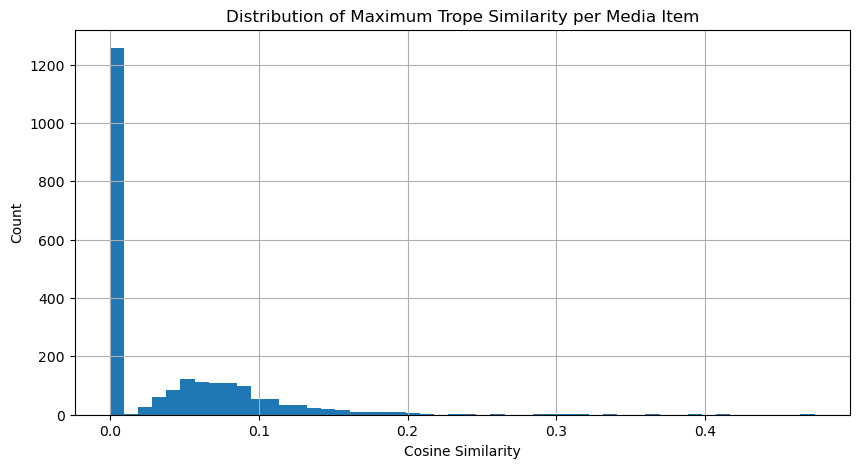

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
modern_df["max_trope_similarity"].hist(bins=50)
plt.title("Distribution of Maximum Trope Similarity per Media Item")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.show()